In [1]:
#IMPORT LIBRARIES

# basic libraries for data handling
import pandas as pd
import numpy as np

# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# make plots look better
sns.set_style("whitegrid")

In [6]:
#LOAD DATA

# load product data
product = pd.read_csv("product_info.csv")

# load all review files
r1 = pd.read_csv("reviews_0-250.csv", low_memory=False)
r2 = pd.read_csv("reviews_250-500.csv", low_memory=False)
r3 = pd.read_csv("reviews_500-750.csv", low_memory=False)
r4 = pd.read_csv("reviews_750-1250.csv", low_memory=False)
r5 = pd.read_csv("reviews_1250-end.csv", low_memory=False)

# combine all review datasets into one
reviews = pd.concat([r1, r2, r3, r4, r5], ignore_index=True)

print("product shape:", product.shape)
print("reviews shape:", reviews.shape)

product shape: (8494, 27)
reviews shape: (1094411, 19)


In [14]:
#basic check

print(product.head())
print(reviews.head(1))

  product_id               product_name  brand_id brand_name  loves_count  \
0    P473671    Fragrance Discovery Set      6342      19-69         6320   
1    P473668    La Habana Eau de Parfum      6342      19-69         3827   
2    P473662  Rainbow Bar Eau de Parfum      6342      19-69         3253   
3    P473660       Kasbah Eau de Parfum      6342      19-69         3018   
4    P473658  Purple Haze Eau de Parfum      6342      19-69         2691   

   rating  reviews            size                      variation_type  \
0  3.6364     11.0             NaN                                 NaN   
1  4.1538     13.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   
2  4.2500     16.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   
3  4.4762     21.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   
4  3.2308     13.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   

  variation_value  ... online_only out_of_stock  sephora_exclusive  \
0             NaN  ...

In [18]:
#1)checking for mising value 

# check missing %
product_missing = product.isnull().mean() * 100
reviews_missing = reviews.isnull().mean() * 100

print(product_missing.sort_values(ascending=False).head(10))
print(reviews_missing.sort_values(ascending=False).head(10))

sale_price_usd       96.821286
value_price_usd      94.690370
variation_desc       85.283730
child_max_price      67.577113
child_min_price      67.577113
highlights           25.983047
size                 19.201789
variation_value      18.813280
variation_type       17.000235
tertiary_category    11.655286
dtype: float64
helpfulness       51.314543
review_title      28.385497
hair_color        20.720552
eye_color         19.154413
skin_tone         15.582720
is_recommended    15.349626
skin_type         10.193337
review_text        0.131943
brand_name         0.000000
product_name       0.000000
dtype: float64


In [20]:
#On above observation,Some columns have high missing values.
#We need to treat them carefully using mean/median/mode.

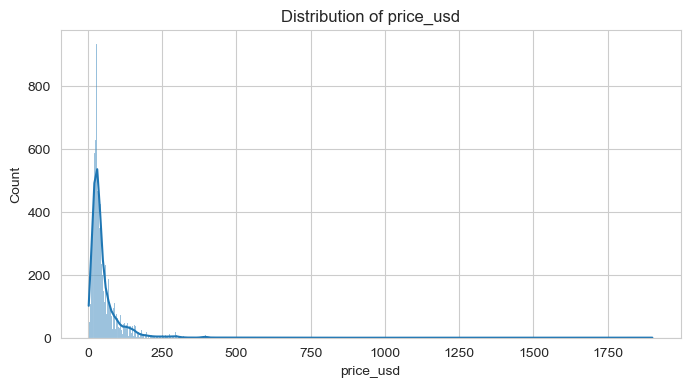

Skewness: 7.379939143356654


In [22]:
#DISTRIBUTION CHECK

col = "price_usd"   # change column if needed

plt.figure(figsize=(8,4))
sns.histplot(product[col].dropna(), kde=True)

plt.title(f"Distribution of {col}")
plt.show()

# check skewness
skew_val = product[col].skew()
print("Skewness:", skew_val)

In [24]:
#observation 

#If graph shows long right tail → Right Skew
#If graph shows long left tail → Left Skew
#If symmetric → Normal

#If skewed → use MEDIAN
#If symmetric → use MEAN

In [29]:
#DECIDE MEAN OR MEDIAN

if abs(skew_val) < 0.5:
    print("Symmetric → use MEAN")
    fill_value = product[col].mean()
else:
    print("Skewed → use MEDIAN")
    fill_value = product[col].median()

Skewed → use MEDIAN


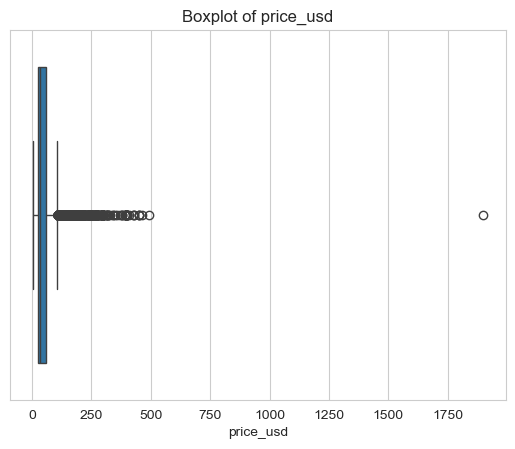

In [31]:
#BOXPLOT (OUTLIERS)

sns.boxplot(x=product[col])
plt.title(f"Boxplot of {col}")
plt.show()

In [33]:
#Outliers are present → mean gets affected
#So median is better choice

In [37]:
#APPLY MISSING VALUE FILL
product[col] = product[col].fillna(fill_value)


Column: price_usd


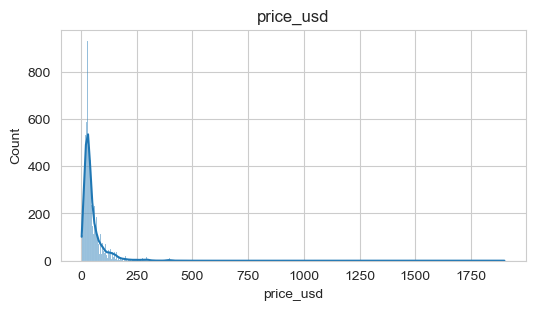

Skewness: 7.379939143356654
→ skewed → use MEDIAN

Column: rating


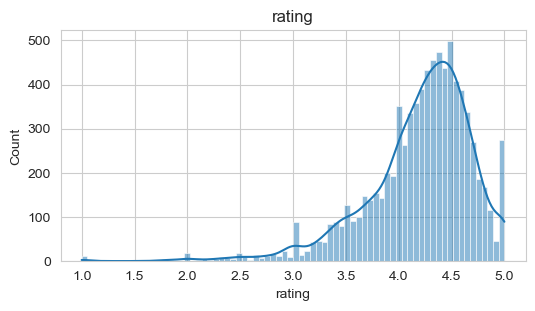

Skewness: -1.51762879552522
→ skewed → use MEDIAN

Column: reviews


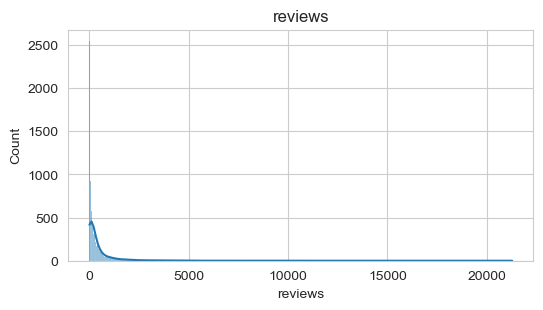

Skewness: 7.87832715151436
→ skewed → use MEDIAN

Column: loves_count


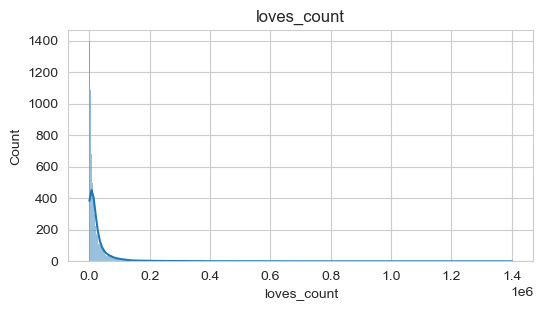

Skewness: 7.2529059013811645
→ skewed → use MEDIAN


In [41]:
#LOOP FOR MULTIPLE COLUMNS

num_cols = ["price_usd", "rating", "reviews", "loves_count"]

for col in num_cols:
    
    print("\nColumn:", col)
    
    plt.figure(figsize=(6,3))
    sns.histplot(product[col].dropna(), kde=True)
    plt.title(col)
    plt.show()
    
    skew_val = product[col].skew()
    print("Skewness:", skew_val)
    
    if abs(skew_val) < 0.5:
        print("→ symmetric → use MEAN")
        fill_value = product[col].mean()
    else:
        print("→ skewed → use MEDIAN")
        fill_value = product[col].median()
    
    product[col] = product[col].fillna(fill_value)

In [45]:
#CATEGORICAL DATA

# fill categorical values
product["brand_name"] = product["brand_name"].fillna("Unknown")
product["primary_category"] = product["primary_category"].fillna("Unknown")

In [47]:
#Categorical columns cannot use mean/median
#So we use mode or 'Unknown'

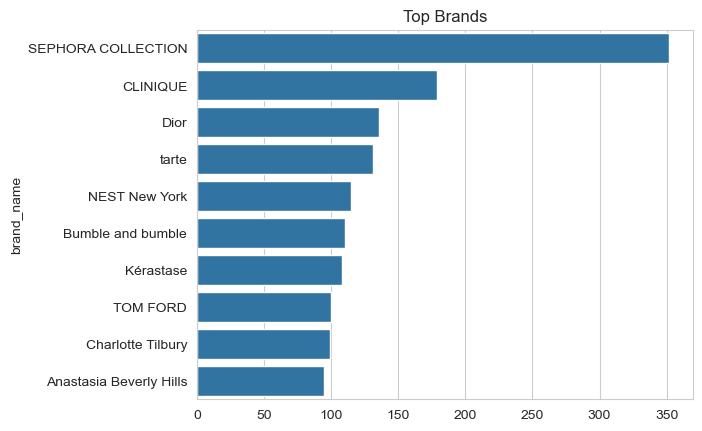

In [52]:
#TOP BRANDS

top_brands = product["brand_name"].value_counts().head(10)

sns.barplot(x=top_brands.values, y=top_brands.index)
plt.title("Top Brands")
plt.show()

In [ ]:
#Few brands dominate the dataset.
#These brands have more products.

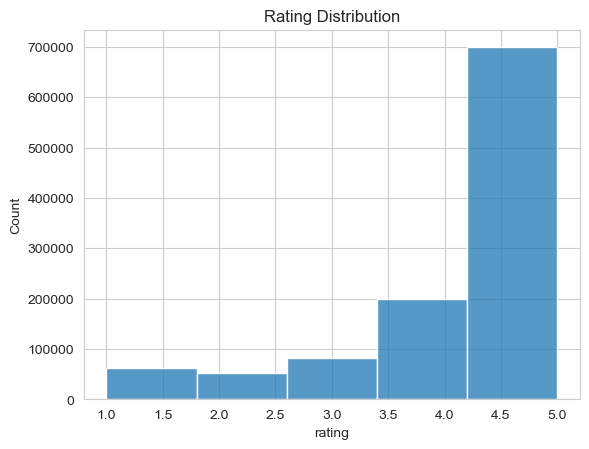

In [54]:
#RATING DISTRIBUTION

sns.histplot(reviews["rating"], bins=5)
plt.title("Rating Distribution")
plt.show()

In [56]:
#Most ratings are high → positive feedback

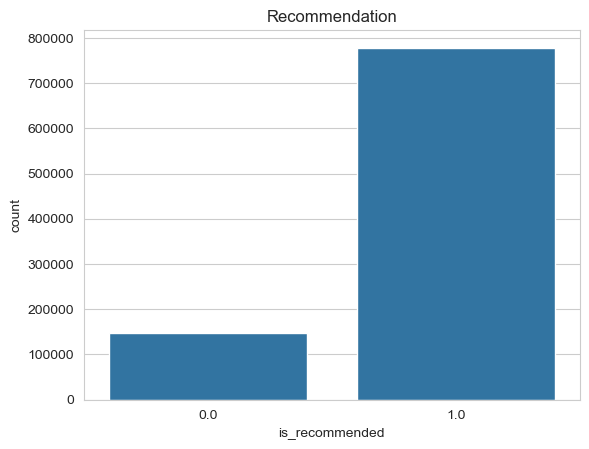

In [58]:
#RECOMMENDATION

sns.countplot(x=reviews["is_recommended"])
plt.title("Recommendation")
plt.show()

In [60]:
#Most users recommend products → good satisfaction

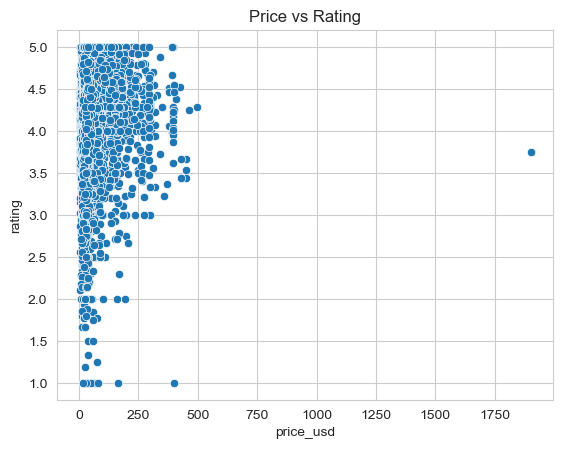

In [64]:
#SCATTER (RELATION)

sns.scatterplot(data=product, x="price_usd", y="rating")
plt.title("Price vs Rating")
plt.show()

In [66]:
#No strong relationship → expensive ≠ better rating

                 price_usd       rating       reviews   loves_count
price_usd      2880.386722     1.553628 -3.283265e+03 -3.178448e+05
rating            1.553628     0.258519  3.746261e+01  1.311200e+03
reviews       -3283.265198    37.462608  1.177992e+06  4.912999e+07
loves_count -317844.811823  1311.199567  4.912999e+07  4.368169e+09


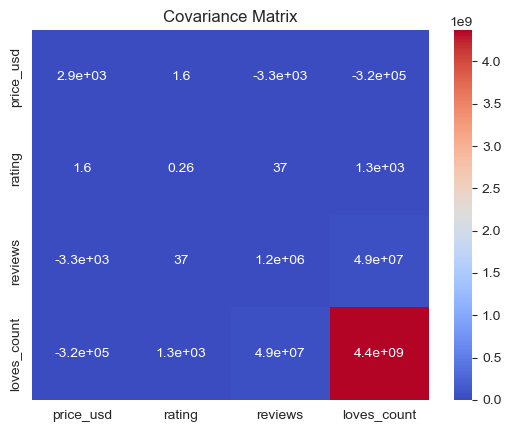

In [76]:
#COVARIANCE

num_cols = ["price_usd", "rating", "reviews", "loves_count"]

cov_matrix = product[num_cols].cov()
print(cov_matrix)


#plot
sns.heatmap(cov_matrix, annot=True, cmap="coolwarm")
plt.title("Covariance Matrix")
plt.show()

In [78]:
#Positive → variables increase together
#Negative → one increases, other decreases

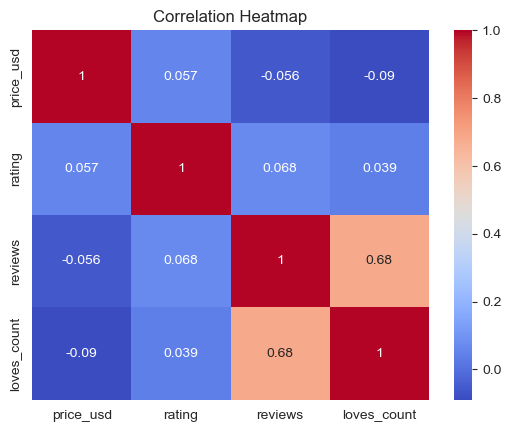

In [83]:
#. CORRELATION

corr_matrix = product[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [85]:
#Closer to +1 → strong positive relation
#Closer to -1 → strong negative relation

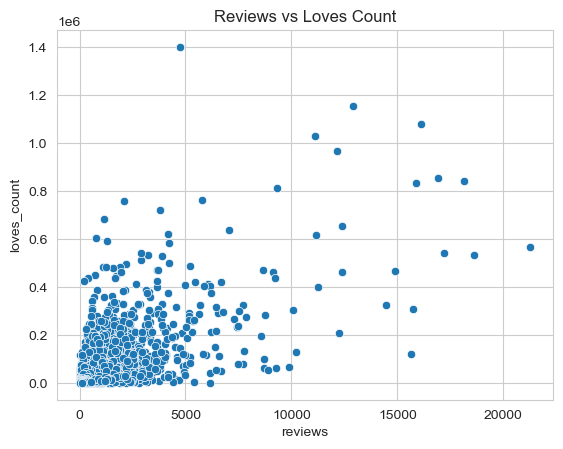

In [93]:
#COLLINEARITY
#Highly correlated features → collinearity
#they give similar information

#Solution:
#Remove one column to avoid overfitting

threshold = 0.8

for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i != j and abs(corr_matrix[i][j]) > threshold:
            print(i, "and", j, "are highly correlated")

sns.scatterplot(data=product, x="reviews", y="loves_count")
plt.title("Reviews vs Loves Count")
plt.show()



In [95]:
#Strong upward trend → positive correlation
#Both features carry similar information

In [97]:
#I analyzed distributions using histogram and KDE plots.

#For symmetric data, I used mean imputation.

#For skewed data and outliers, I used median imputation.

#Categorical values were filled using mode or 'Unknown'.

#Covariance and correlation were used to understand relationships between variables.

#Highly correlated features were identified as collinear and considered for removal to prevent overfitting.